In [1]:
# ============================================================
# Phase 1 - Vision Transformer Experiment
# Calorify Visual Food Recognition
# Strong ViT GPU-Ready Version
# Notebook: Phase1_05_VisionTransformer_Experiment.ipynb
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# ============================================================
# Reproducibility
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Device Check
# ============================================================

gpu_devices = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(gpu_devices) > 0

print("TensorFlow version:", tf.__version__)
print("GPU Available:", GPU_AVAILABLE)

if GPU_AVAILABLE:
    print("GPU devices:", gpu_devices)
else:
    print("WARNING: No GPU detected.")
    print("This is a strong ViT configuration and may train very slowly on CPU.")

# ============================================================
# Main Project Paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/Calorify/phase1_clean"

RESULTS_DIR = os.path.join(PROJECT_DIR, "results", "vit")
MODELS_DIR = os.path.join(PROJECT_DIR, "models", "vit")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("\nProject directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Models directory:", MODELS_DIR)

print("\nPROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("RESULTS_DIR exists:", os.path.exists(RESULTS_DIR))
print("MODELS_DIR exists:", os.path.exists(MODELS_DIR))

# ============================================================
# Strong ViT Configuration
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 10
AUTOTUNE = tf.data.AUTOTUNE

PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

PROJECTION_DIM = 128
NUM_HEADS = 8
TRANSFORMER_LAYERS = 8

MLP_HEAD_UNITS = [512, 256]
TRANSFORMER_UNITS = [
    PROJECTION_DIM * 2,
    PROJECTION_DIM
]

DROPOUT_RATE = 0.1
EPOCHS = 20
LEARNING_RATE = 1e-4

print("\nStrong ViT Configuration:")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Patch size:", PATCH_SIZE)
print("Number of patches:", NUM_PATCHES)
print("Projection dim:", PROJECTION_DIM)
print("Number of heads:", NUM_HEADS)
print("Transformer layers:", TRANSFORMER_LAYERS)
print("MLP head units:", MLP_HEAD_UNITS)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Mounted at /content/drive
TensorFlow version: 2.20.0
GPU Available: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Project directory: /content/drive/MyDrive/Calorify/phase1_clean
Results directory: /content/drive/MyDrive/Calorify/phase1_clean/results/vit
Models directory: /content/drive/MyDrive/Calorify/phase1_clean/models/vit

PROJECT_DIR exists: True
RESULTS_DIR exists: True
MODELS_DIR exists: True

Strong ViT Configuration:
Image size: 224
Batch size: 16
Patch size: 16
Number of patches: 196
Projection dim: 128
Number of heads: 8
Transformer layers: 8
MLP head units: [512, 256]
Epochs: 20
Learning rate: 0.0001


In [2]:
# ============================================================
# Cell 2 - Detect Train/Val/Test Split and Load Datasets
# ============================================================

def count_images_in_dir(directory):
    valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    total = 0
    for root, dirs, files in os.walk(directory):
        total += sum(1 for f in files if f.lower().endswith(valid_exts))
    return total


def find_split_root(project_dir):
    """
    Search for a folder that contains train + val/validation + test.
    """
    candidates = []

    for root, dirs, files in os.walk(project_dir):
        dir_names = set(dirs)

        has_train = "train" in dir_names
        has_test = "test" in dir_names
        has_val = "val" in dir_names or "validation" in dir_names

        if has_train and has_val and has_test:
            candidates.append(root)

    if not candidates:
        raise FileNotFoundError(
            "Could not find a split folder containing train, val/validation, and test."
        )

    # Prefer shortest path because it is usually the main split root
    candidates = sorted(candidates, key=len)
    return candidates[0]


# Detect split root
SPLIT_DIR = find_split_root(PROJECT_DIR)

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

if os.path.exists(os.path.join(SPLIT_DIR, "val")):
    VAL_DIR = os.path.join(SPLIT_DIR, "val")
else:
    VAL_DIR = os.path.join(SPLIT_DIR, "validation")

print("Detected split directory:", SPLIT_DIR)
print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)
print("Test directory:", TEST_DIR)

print("\nImage counts:")
print("Train images:", count_images_in_dir(TRAIN_DIR))
print("Validation images:", count_images_in_dir(VAL_DIR))
print("Test images:", count_images_in_dir(TEST_DIR))

# ------------------------------------------------------------
# Load class names from existing class_names.json if available
# ------------------------------------------------------------

possible_class_json_paths = [
    os.path.join(PROJECT_DIR, "class_names.json"),
    os.path.join(PROJECT_DIR, "metadata", "class_names.json"),
    os.path.join(PROJECT_DIR, "results", "class_names.json"),
]

CLASS_NAMES_PATH = None

for path in possible_class_json_paths:
    if os.path.exists(path):
        CLASS_NAMES_PATH = path
        break

if CLASS_NAMES_PATH:
    with open(CLASS_NAMES_PATH, "r") as f:
        loaded_class_names = json.load(f)

    # Handle both list and dict formats
    if isinstance(loaded_class_names, dict):
        class_names = [loaded_class_names[str(i)] for i in range(len(loaded_class_names))]
    else:
        class_names = loaded_class_names

    print("\nLoaded class names from:", CLASS_NAMES_PATH)
else:
    class_names = None
    print("\nNo class_names.json found. Keras will infer class names from folders.")

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("\nFinal class names:")
print(class_names)
print("Number of classes:", NUM_CLASSES)

# ------------------------------------------------------------
# Performance optimization
# ------------------------------------------------------------

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("\nDatasets loaded successfully.")

Detected split directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split
Train directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/train
Validation directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/val
Test directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/test

Image counts:
Train images: 3413
Validation images: 731
Test images: 732

Loaded class names from: /content/drive/MyDrive/Calorify/phase1_clean/metadata/class_names.json
Found 3413 files belonging to 10 classes.
Found 731 files belonging to 10 classes.
Found 732 files belonging to 10 classes.

Final class names:
['burger', 'pizza', 'fries', 'pasta', 'rice', 'chicken', 'salad', 'sandwich', 'sushi', 'steak']
Number of classes: 10

Datasets loaded successfully.


In [3]:
# ============================================================
# Cell 3 - Dataset Distribution Check
# ============================================================

def count_images_per_class(split_dir, class_names):
    valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    counts = {}

    for class_name in class_names:
        class_dir = os.path.join(split_dir, class_name)
        total = 0

        if os.path.exists(class_dir):
            for file_name in os.listdir(class_dir):
                if file_name.lower().endswith(valid_exts):
                    total += 1

        counts[class_name] = total

    return counts


train_counts = count_images_per_class(TRAIN_DIR, class_names)
val_counts = count_images_per_class(VAL_DIR, class_names)
test_counts = count_images_per_class(TEST_DIR, class_names)

distribution_df = pd.DataFrame({
    "class_name": class_names,
    "train": [train_counts[c] for c in class_names],
    "validation": [val_counts[c] for c in class_names],
    "test": [test_counts[c] for c in class_names],
})

distribution_df["total"] = (
    distribution_df["train"] +
    distribution_df["validation"] +
    distribution_df["test"]
)

distribution_path = os.path.join(RESULTS_DIR, "vit_dataset_distribution.csv")
distribution_df.to_csv(distribution_path, index=False)

print("Dataset distribution saved to:")
print(distribution_path)

display(distribution_df)

print("\nTotals:")
print("Train:", distribution_df["train"].sum())
print("Validation:", distribution_df["validation"].sum())
print("Test:", distribution_df["test"].sum())
print("Total:", distribution_df["total"].sum())

Dataset distribution saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_dataset_distribution.csv


,class_name,train,validation,test,total
0,burger,350,75,75,500
1,pizza,350,75,75,500
2,fries,350,75,75,500
3,pasta,350,75,75,500
4,rice,301,64,65,430
5,chicken,350,75,75,500
6,salad,350,75,75,500
7,sandwich,350,75,75,500
8,sushi,312,67,67,446
9,steak,350,75,75,500



Totals:
Train: 3413
Validation: 731
Test: 732
Total: 4876


In [4]:
# ============================================================
# Cell 4 - Load or Compute Class Weights
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Try to find existing class weights file
possible_class_weights_paths = [
    os.path.join(PROJECT_DIR, "metadata", "class_weights.csv"),
    os.path.join(PROJECT_DIR, "class_weights.csv"),
    os.path.join(RESULTS_DIR, "class_weights.csv"),
]

CLASS_WEIGHTS_PATH = None

for path in possible_class_weights_paths:
    if os.path.exists(path):
        CLASS_WEIGHTS_PATH = path
        break

if CLASS_WEIGHTS_PATH:
    class_weights_df = pd.read_csv(CLASS_WEIGHTS_PATH)
    print("Loaded class weights from:")
    print(CLASS_WEIGHTS_PATH)
    display(class_weights_df)

    # Flexible handling depending on column names
    if "class_id" in class_weights_df.columns and "class_weight" in class_weights_df.columns:
        class_weights = {
            int(row["class_id"]): float(row["class_weight"])
            for _, row in class_weights_df.iterrows()
        }
    elif "class_name" in class_weights_df.columns and "class_weight" in class_weights_df.columns:
        class_to_id = {name: idx for idx, name in enumerate(class_names)}
        class_weights = {
            class_to_id[row["class_name"]]: float(row["class_weight"])
            for _, row in class_weights_df.iterrows()
        }
    else:
        raise ValueError("class_weights.csv found, but column names are not recognized.")

else:
    print("No class_weights.csv found. Computing class weights from train distribution.")

    y_train_labels = []
    for class_id, class_name in enumerate(class_names):
        y_train_labels.extend([class_id] * train_counts[class_name])

    y_train_labels = np.array(y_train_labels)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_train_labels
    )

    class_weights = {i: float(weights[i]) for i in range(NUM_CLASSES)}

    class_weights_df = pd.DataFrame({
        "class_id": list(class_weights.keys()),
        "class_name": class_names,
        "class_weight": list(class_weights.values())
    })

    computed_path = os.path.join(RESULTS_DIR, "vit_class_weights.csv")
    class_weights_df.to_csv(computed_path, index=False)

    print("Computed class weights saved to:")
    print(computed_path)
    display(class_weights_df)

print("\nFinal class_weights dictionary:")
print(class_weights)

Loaded class weights from:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/class_weights.csv


,class_index,class_name,train_count,class_weight
0,0,burger,350,0.975143
1,1,pizza,350,0.975143
2,2,fries,350,0.975143
3,3,pasta,350,0.975143
4,4,rice,301,1.133887
5,5,chicken,350,0.975143
6,6,salad,350,0.975143
7,7,sandwich,350,0.975143
8,8,sushi,312,1.093910
9,9,steak,350,0.975143



Final class_weights dictionary:
{0: 0.9751428571428572, 1: 0.9751428571428572, 2: 0.9751428571428572, 3: 0.9751428571428572, 4: 1.1338870431893688, 5: 0.9751428571428572, 6: 0.9751428571428572, 7: 0.9751428571428572, 8: 1.0939102564102563, 9: 0.9751428571428572}


In [5]:
# ============================================================
# Cell 5 - Data Augmentation and Normalization Layers
# ============================================================

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="vit_data_augmentation"
)

normalization_layer = layers.Rescaling(1.0 / 255.0, name="vit_rescaling")

print("Data augmentation layer:")
data_augmentation.summary()

print("\nNormalization layer created successfully.")

# Test one batch shape
for images, labels in train_ds.take(1):
    print("\nOriginal batch image shape:", images.shape)
    print("Original batch label shape:", labels.shape)

    augmented_images = data_augmentation(images, training=True)
    normalized_images = normalization_layer(augmented_images)

    print("Augmented batch image shape:", augmented_images.shape)
    print("Normalized batch image shape:", normalized_images.shape)
    print("Pixel range after normalization:")
    print("Min:", tf.reduce_min(normalized_images).numpy())
    print("Max:", tf.reduce_max(normalized_images).numpy())

Data augmentation layer:


Model: "vit_data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Normalization layer created successfully.

Original batch image shape: (16, 224, 224, 3)
Original batch label shape: (16,)
Augmented batch image shape: (16, 224, 224, 3)
Normalized batch image shape: (16, 224, 224, 3)
Pixel range after normalization:
Min: 0.0
Max: 1.0


In [6]:
# ============================================================
# Cell 6 - ViT Patch Extraction and Patch Encoder
# ============================================================

class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )

        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])

        return patches

    def get_config(self):
        config = super().get_config()
        config.update({
            "patch_size": self.patch_size
        })
        return config


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.expand_dims(
            tf.range(start=0, limit=self.num_patches, delta=1),
            axis=0
        )

        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config


# ------------------------------------------------------------
# Quick test on one batch
# ------------------------------------------------------------

for images, labels in train_ds.take(1):
    normalized_images = normalization_layer(images)

    patches_layer = Patches(PATCH_SIZE, name="patch_extraction")
    patches = patches_layer(normalized_images)

    patch_encoder = PatchEncoder(NUM_PATCHES, PROJECTION_DIM, name="patch_encoder")
    encoded_patches = patch_encoder(patches)

    print("Input image batch shape:", normalized_images.shape)
    print("Patches shape:", patches.shape)
    print("Encoded patches shape:", encoded_patches.shape)

    print("\nExpected:")
    print("Number of patches:", NUM_PATCHES)
    print("Patch vector size:", PATCH_SIZE * PATCH_SIZE * 3)
    print("Projection dim:", PROJECTION_DIM)

Input image batch shape: (16, 224, 224, 3)
Patches shape: (16, 196, 768)
Encoded patches shape: (16, 196, 128)

Expected:
Number of patches: 196
Patch vector size: 768
Projection dim: 128


In [7]:
# ============================================================
# Cell 7 - Build Strong Regularized Vision Transformer Model
# ============================================================

def mlp(x, hidden_units, dropout_rate, name_prefix="mlp"):
    for i, units in enumerate(hidden_units):
        x = layers.Dense(
            units,
            activation=tf.nn.gelu,
            name=f"{name_prefix}_dense_{i+1}",
            kernel_regularizer=keras.regularizers.l2(1e-4)
        )(x)
        x = layers.Dropout(dropout_rate, name=f"{name_prefix}_dropout_{i+1}")(x)
    return x


def build_vit_classifier():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

    # Augmentation + normalization
    x = data_augmentation(inputs)
    x = normalization_layer(x)

    # Create patches
    patches = Patches(PATCH_SIZE, name="patch_extraction")(x)

    # Encode patches
    encoded_patches = PatchEncoder(
        NUM_PATCHES,
        PROJECTION_DIM,
        name="patch_encoder"
    )(patches)

    # Important:
    # key_dim is per attention head, not the full projection dimension
    attention_key_dim = PROJECTION_DIM // NUM_HEADS

    # Transformer encoder blocks
    for layer_idx in range(TRANSFORMER_LAYERS):

        x1 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_block_{layer_idx+1}_ln_1"
        )(encoded_patches)

        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=attention_key_dim,
            dropout=DROPOUT_RATE,
            name=f"transformer_block_{layer_idx+1}_mha"
        )(x1, x1)

        x2 = layers.Add(name=f"transformer_block_{layer_idx+1}_skip_1")(
            [attention_output, encoded_patches]
        )

        x3 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_block_{layer_idx+1}_ln_2"
        )(x2)

        x3 = mlp(
            x3,
            hidden_units=TRANSFORMER_UNITS,
            dropout_rate=DROPOUT_RATE,
            name_prefix=f"transformer_block_{layer_idx+1}_mlp"
        )

        encoded_patches = layers.Add(name=f"transformer_block_{layer_idx+1}_skip_2")(
            [x3, x2]
        )

    # Final representation
    representation = layers.LayerNormalization(
        epsilon=1e-6,
        name="final_layer_norm"
    )(encoded_patches)

    # Better than Flatten for smaller dataset
    representation = layers.GlobalAveragePooling1D(
        name="global_average_pooling_patches"
    )(representation)

    representation = layers.Dropout(0.3, name="pre_head_dropout")(representation)

    # Classification head
    features = mlp(
        representation,
        hidden_units=[256, 128],
        dropout_rate=0.3,
        name_prefix="classification_head"
    )

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="food_class_output"
    )(features)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="ViT_Strong_Regularized_Food_Classifier"
    )

    return model


vit_model = build_vit_classifier()

vit_model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.summary()

# Save model architecture summary as text
summary_path = os.path.join(RESULTS_DIR, "vit_model_summary.txt")

with open(summary_path, "w") as f:
    vit_model.summary(print_fn=lambda x: f.write(x + "\n"))

print("\nModel summary saved to:")
print(summary_path)

Model: "ViT_Strong_Regularized_Food_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_data_augmentat… │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_rescaling       │ (None, 224, 224,  │          0 │ vit_data_augment… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extraction    │ (None, None, 768) │          0 │ vit_rescaling[0]… │
│ (Patches)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 128)  │    123,520 │ patch_extraction… │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │        256 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │     66,048 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │          0 │ transformer_bloc… │
│ (Add)               │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 256)  │     33,024 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 256)  │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │     32,896 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │          0 │ transformer_bloc… │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │     66,048 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 196, 128)  │          0 │ transformer_bloc

 Total params: 1,250,826 (4.77 MB)

 Trainable params: 1,250,826 (4.77 MB)

 Non-trainable params: 0 (0.00 B)


Model summary saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_model_summary.txt


In [8]:
# ============================================================
# Cell 8 - Train Vision Transformer Model
# ============================================================

checkpoint_path = os.path.join(MODELS_DIR, "vit_best_model.keras")
weights_path = os.path.join(MODELS_DIR, "vit_best_weights.weights.h5")
history_path = os.path.join(RESULTS_DIR, "vit_training_history.csv")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Starting ViT training...")
print("Checkpoint path:", checkpoint_path)
print("Weights path:", weights_path)
print("History path:", history_path)

history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Save final weights
vit_model.save_weights(weights_path)

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv(history_path, index=False)

print("\nTraining completed.")
print("Best model saved to:", checkpoint_path)
print("Final weights saved to:", weights_path)
print("Training history saved to:", history_path)

display(history_df.tail())

Starting ViT training...
Checkpoint path: /content/drive/MyDrive/Calorify/phase1_clean/models/vit/vit_best_model.keras
Weights path: /content/drive/MyDrive/Calorify/phase1_clean/models/vit/vit_best_weights.weights.h5
History path: /content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_training_history.csv
Epoch 1/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1248 - loss: 2.6521
Epoch 1: val_accuracy improved from None to 0.12722, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/vit/vit_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/vit/vit_best_model.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 1092s 5s/step - accuracy: 0.1342 - loss: 2.6148 - val_accuracy: 0.1272 - val_loss: 2.5520 - learning_rate: 1.0000e-04
Epoch 2/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.1686 - loss: 2.5307
Epoch 2: val_accuracy improved from 0.12722 to 0.19973, saving model to /content/drive/MyDrive/Calorify/phase

,accuracy,loss,val_accuracy,val_loss,learning_rate
15,0.497803,1.756734,0.482900,1.791956,0.000050
16,0.512159,1.734390,0.491108,1.773399,0.000050
17,0.514503,1.713722,0.496580,1.793972,0.000050
18,0.521242,1.703621,0.493844,1.837031,0.000050
19,0.530911,1.655670,0.511628,1.755385,0.000025


In [9]:
# ============================================================
# Cell 9 - Evaluate ViT Model on Test Set
# ============================================================

print("Evaluating ViT model on the test set...")

test_loss, test_accuracy = vit_model.evaluate(test_ds, verbose=1)

best_val_accuracy = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])
best_val_loss_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_accuracy_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)

vit_basic_results = {
    "model_name": "Vision Transformer",
    "model_type": "Transformer-based Visual Model",
    "training_strategy": "ViT trained from scratch",
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "best_validation_accuracy": best_val_accuracy,
    "best_validation_accuracy_epoch": best_val_accuracy_epoch,
    "best_validation_loss": best_val_loss,
    "best_validation_loss_epoch": best_val_loss_epoch,
    "total_epochs_trained": len(history.history["accuracy"]),
    "notes": "ViT from scratch included for transformer-based visual model comparison."
}

vit_basic_results_df = pd.DataFrame([vit_basic_results])

basic_results_path = os.path.join(RESULTS_DIR, "vit_basic_test_results.csv")
vit_basic_results_df.to_csv(basic_results_path, index=False)

print("\nViT Basic Test Results:")
display(vit_basic_results_df)

print("\nSaved to:")
print(basic_results_path)

Evaluating ViT model on the test set...
46/46 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.5738 - loss: 1.6122

ViT Basic Test Results:


,model_name,model_type,training_strategy,test_accuracy,test_loss,best_validation_accuracy,best_validation_accuracy_epoch,best_validation_loss,best_validation_loss_epoch,total_epochs_trained,notes
0,Vision Transformer,Transformer-based Visual Model,ViT trained from scratch,0.57377,1.612194,0.511628,20,1.755385,20,20,ViT from scratch included for transformer-base...



Saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_basic_test_results.csv


In [10]:
# ============================================================
# Cell 10 - ViT Predictions and Classification Report
# ============================================================

print("Generating predictions on test set...")

y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = vit_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# Metrics
test_acc_from_preds = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

correct_predictions = int(np.sum(y_true == y_pred))
wrong_predictions = int(np.sum(y_true != y_pred))

print("Test Accuracy from predictions:", test_acc_from_preds)
print("Macro F1-score:", macro_f1)
print("Weighted F1-score:", weighted_f1)
print("Correct predictions:", correct_predictions)
print("Wrong predictions:", wrong_predictions)

# Classification report
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

classification_report_path = os.path.join(
    RESULTS_DIR,
    "vit_classification_report.csv"
)

report_df.to_csv(classification_report_path)

print("\nClassification report saved to:")
print(classification_report_path)

display(report_df)

Generating predictions on test set...
Test Accuracy from predictions: 0.5737704918032787
Macro F1-score: 0.5668439500018495
Weighted F1-score: 0.5656592076040655
Correct predictions: 420
Wrong predictions: 312

Classification report saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_classification_report.csv


,precision,recall,f1-score,support
burger,0.485714,0.680000,0.566667,75.00000
pizza,0.520548,0.506667,0.513514,75.00000
fries,0.580645,0.720000,0.642857,75.00000
pasta,0.775000,0.413333,0.539130,75.00000
rice,0.733333,0.507692,0.600000,65.00000
chicken,0.492308,0.426667,0.457143,75.00000
salad,0.800000,0.800000,0.800000,75.00000
sandwich,0.395833,0.253333,0.308943,75.00000
sushi,0.600000,0.671642,0.633803,67.00000
steak,0.504425,0.760000,0.606383,75.00000


Confusion matrix saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_confusion_matrix.csv


,burger,pizza,fries,pasta,rice,chicken,salad,sandwich,sushi,steak
burger,51,3,3,0,0,3,0,6,3,6
pizza,2,38,4,1,6,6,1,4,5,8
fries,4,4,54,3,0,5,0,1,1,3
pasta,4,10,15,31,1,5,2,2,3,2
rice,2,2,4,3,33,1,3,3,5,9
chicken,10,2,4,0,0,32,3,8,3,13
salad,3,0,0,1,2,2,60,1,3,3
sandwich,24,8,6,0,0,1,3,19,4,10
sushi,3,4,3,0,1,4,1,4,45,2
steak,2,2,0,1,2,6,2,0,3,57


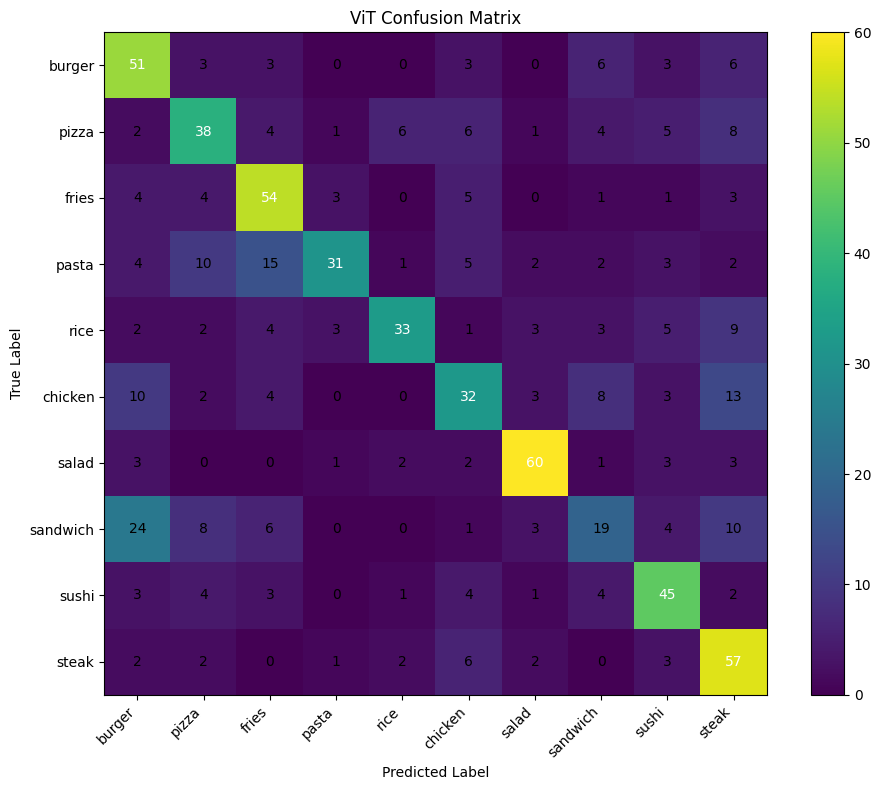

Confusion matrix image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_confusion_matrix.png


In [11]:
# ============================================================
# Cell 11 - Confusion Matrix for ViT
# ============================================================

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

confusion_matrix_csv_path = os.path.join(
    RESULTS_DIR,
    "vit_confusion_matrix.csv"
)

cm_df.to_csv(confusion_matrix_csv_path)

print("Confusion matrix saved to:")
print(confusion_matrix_csv_path)

display(cm_df)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("ViT Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

# Add numbers inside cells
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_png_path = os.path.join(
    RESULTS_DIR,
    "vit_confusion_matrix.png"
)

plt.savefig(confusion_matrix_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix image saved to:")
print(confusion_matrix_png_path)

In [12]:
# ============================================================
# Cell 12 - Wrong Predictions Analysis for ViT
# ============================================================

import glob
from PIL import Image

# Reconstruct test image paths in the same folder/class order
valid_exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]

test_image_paths = []

for class_name in class_names:
    class_dir = os.path.join(TEST_DIR, class_name)
    class_files = []

    for ext in valid_exts:
        class_files.extend(glob.glob(os.path.join(class_dir, ext)))
        class_files.extend(glob.glob(os.path.join(class_dir, ext.upper())))

    class_files = sorted(class_files)
    test_image_paths.extend(class_files)

print("Number of test image paths:", len(test_image_paths))
print("Number of predictions:", len(y_pred))

if len(test_image_paths) != len(y_pred):
    print("WARNING: Number of paths does not match number of predictions.")
    print("Wrong prediction CSV will still be created without guaranteed exact image-path alignment.")

# Build prediction dataframe
prediction_rows = []

for i in range(len(y_true)):
    true_id = int(y_true[i])
    pred_id = int(y_pred[i])

    true_class = class_names[true_id]
    pred_class = class_names[pred_id]

    confidence = float(np.max(y_probs[i]))
    correct = true_id == pred_id

    image_path = test_image_paths[i] if i < len(test_image_paths) else ""

    prediction_rows.append({
        "image_path": image_path,
        "true_class": true_class,
        "predicted_class": pred_class,
        "confidence": confidence,
        "correct": correct
    })

predictions_df = pd.DataFrame(prediction_rows)

wrong_predictions_df = predictions_df[predictions_df["correct"] == False].copy()
wrong_predictions_df = wrong_predictions_df.sort_values(
    by="confidence",
    ascending=False
)

wrong_predictions_path = os.path.join(
    RESULTS_DIR,
    "vit_wrong_predictions.csv"
)

wrong_predictions_df.to_csv(wrong_predictions_path, index=False)

print("Wrong predictions saved to:")
print(wrong_predictions_path)

print("\nTotal predictions:", len(predictions_df))
print("Correct predictions:", int(predictions_df["correct"].sum()))
print("Wrong predictions:", len(wrong_predictions_df))

display(wrong_predictions_df.head(20))

# ------------------------------------------------------------
# Plot sample wrong predictions
# ------------------------------------------------------------

sample_wrong = wrong_predictions_df.head(12)

plt.figure(figsize=(16, 12))

for idx, (_, row) in enumerate(sample_wrong.iterrows()):
    image_path = row["image_path"]

    plt.subplot(3, 4, idx + 1)

    try:
        img = Image.open(image_path).convert("RGB")
        plt.imshow(img)
    except Exception:
        plt.text(0.5, 0.5, "Image load error", ha="center", va="center")

    plt.axis("off")
    plt.title(
        f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']:.2f}",
        fontsize=10
    )

plt.tight_layout()

wrong_samples_path = os.path.join(
    RESULTS_DIR,
    "vit_wrong_prediction_samples.png"
)

plt.savefig(wrong_samples_path, dpi=300, bbox_inches="tight")
plt.show()

print("Wrong prediction samples image saved to:")
print(wrong_samples_path)

Output hidden; open in https://colab.research.google.com to view.

In [13]:
# ============================================================
# Cell 13 - Final ViT Summary
# ============================================================

vit_final_summary = {
    "model_name": "Vision Transformer",
    "model_type": "Transformer-based Visual Model",
    "training_strategy": "ViT trained from scratch using image patches and transformer encoder blocks",
    "weights_file": weights_path,
    "model_file": checkpoint_path,
    "history_file": history_path,
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "best_validation_accuracy": float(best_val_accuracy),
    "best_validation_accuracy_epoch": int(best_val_accuracy_epoch),
    "best_validation_loss": float(best_val_loss),
    "best_validation_loss_epoch": int(best_val_loss_epoch),
    "macro_f1_score": float(macro_f1),
    "weighted_f1_score": float(weighted_f1),
    "correct_predictions": int(correct_predictions),
    "wrong_predictions": int(wrong_predictions),
    "total_test_samples": int(len(y_true)),
    "status": "Completed",
    "notes": (
        "ViT was included to represent transformer-based visual modeling. "
        "The model was trained from scratch, so performance is expected to be lower "
        "than pretrained CNN models such as EfficientNetB0, MobileNetV2, and ResNet50."
    )
}

vit_final_summary_df = pd.DataFrame([vit_final_summary])

vit_final_summary_csv_path = os.path.join(
    RESULTS_DIR,
    "vit_final_summary.csv"
)

vit_final_summary_txt_path = os.path.join(
    RESULTS_DIR,
    "vit_final_summary.txt"
)

vit_final_summary_df.to_csv(vit_final_summary_csv_path, index=False)

with open(vit_final_summary_txt_path, "w") as f:
    f.write("Final Summary — Vision Transformer Experiment\n")
    f.write("=" * 55 + "\n\n")
    for key, value in vit_final_summary.items():
        f.write(f"{key}: {value}\n")

print("ViT final summary saved to:")
print(vit_final_summary_csv_path)
print(vit_final_summary_txt_path)

display(vit_final_summary_df)

ViT final summary saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_final_summary.csv
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_final_summary.txt


,model_name,model_type,training_strategy,weights_file,model_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_accuracy_epoch,best_validation_loss,best_validation_loss_epoch,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,total_test_samples,status,notes
0,Vision Transformer,Transformer-based Visual Model,ViT trained from scratch using image patches a...,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.57377,1.612194,0.511628,20,1.755385,20,0.566844,0.565659,420,312,732,Completed,ViT was included to represent transformer-base...


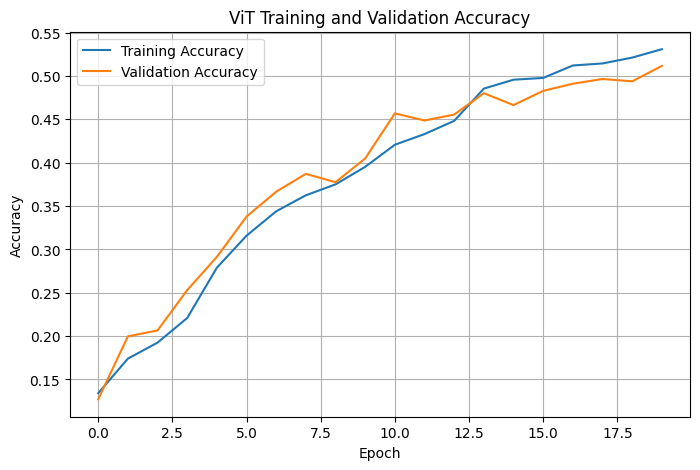

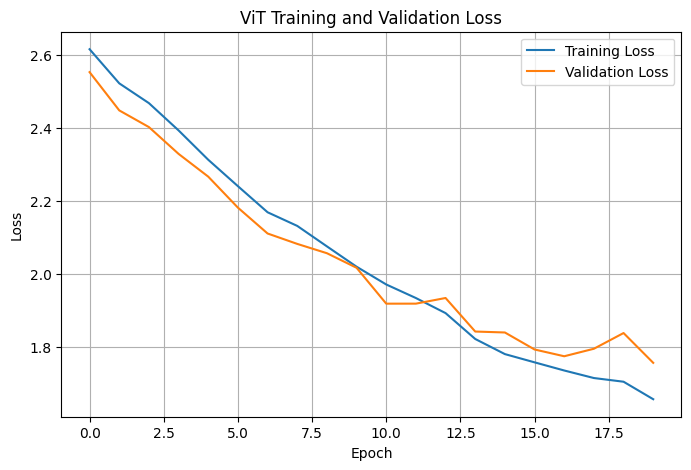

Accuracy curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_accuracy_curve.png

Loss curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_loss_curve.png


In [14]:
# ============================================================
# Cell 14 - ViT Training Curves
# ============================================================

history_df = pd.read_csv(history_path)

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("ViT Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_curve_path = os.path.join(RESULTS_DIR, "vit_accuracy_curve.png")
plt.savefig(accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("ViT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_curve_path = os.path.join(RESULTS_DIR, "vit_loss_curve.png")
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved to:")
print(accuracy_curve_path)

print("\nLoss curve saved to:")
print(loss_curve_path)

In [16]:
# Final Summary — Vision Transformer Experiment
#
# In this notebook, a Vision Transformer (ViT) model was implemented and trained for food image classification as part of Phase 1 of the Calorify project.
#
# Purpose of the Experiment
#
# The ViT model was included to represent transformer-based visual modeling and to compare attention-based image classification against CNN-based and pretrained CNN architectures.
#
# Architecture Overview
#
# The model follows the Vision Transformer concept:
#
# - Input image size: 224 × 224 × 3
# - Patch size: 16 × 16
# - Number of image patches: 196
# - Patch embedding dimension: 128
# - Multi-head self-attention layers
# - Transformer encoder blocks
# - Global average pooling over patch representations
# - Dense classification head
# - Output classes: 10 food categories
#
# Training Strategy
#
# The model was trained from scratch using the same train, validation, and test split used for all Phase 1 models.
#
# Regularization techniques were applied to reduce overfitting:
#
# - Data augmentation
# - Dropout
# - L2 regularization
# - AdamW optimizer with weight decay
# - ReduceLROnPlateau
# - EarlyStopping
# - ModelCheckpoint
#
# Final Results
#
# - Test Accuracy: 57.38%
# - Test Loss: 1.6122
# - Best Validation Accuracy: 51.16%
# - Macro F1-score: 56.68%
# - Weighted F1-score: 56.57%
# - Correct Predictions: 420
# - Wrong Predictions: 312
# - Total Test Samples: 732
#
# Interpretation
#
# The ViT model successfully learned meaningful visual patterns from the dataset.
# Training and validation curves improved steadily, and there was no strong overfitting gap between training and validation accuracy.
#
# However, the ViT model performed lower than pretrained CNN models such as MobileNetV2, EfficientNetB0, and ResNet50.
# This is expected because the ViT model was trained from scratch, while the CNN-based transfer learning models used pretrained ImageNet features.
#
# Error Analysis
#
# The model performed better on visually distinctive classes such as salad, fries, steak, sushi, and burger.
#
# Most errors occurred between visually similar or mixed-food classes, such as:
#
# - sandwich confused with burger
# - chicken confused with steak or fries
# - pasta confused with fries or pizza
# - rice confused with steak or sushi
#
# Some wrong predictions also involved noisy or mixed-content images, where multiple food items appeared in the same image.
#
# Conclusion
#
# The Vision Transformer experiment completed the transformer-based visual modeling requirement for Phase 1.
# Although it did not outperform pretrained CNN models, it provided an important architectural comparison and showed the limitations of training ViT from scratch on a relatively small food image dataset.